In [1]:
import math
import sys
from pathlib import Path

_here = Path().resolve()
for _p in [_here, *_here.parents]:
    _src = _p / "src"
    if (_src / "qudits_on_qubits" / "__init__.py").is_file():
        repo_root = _p
        if str(_src) not in sys.path:
            sys.path.insert(0, str(_src))
        break
else:
    raise ImportError("qudits_on_qubits repo root not found; run the notebook from notebooks/ or the repo root")

import numpy as np
import pandas as pd
from qiskit import qpy, transpile
from qiskit_aer.primitives import SamplerV2 as AerSampler

from qudits_on_qubits.bell_measurements.sampler_circuits import (
    build_sampler_circuits_for_candidate,
    decoding_kwargs_from_metadata,
    run_sampler_circuits_to_counts_by_setting,
)
from qudits_on_qubits.bell_measurements.postprocessing import compute_bell_value_from_counts
from qudits_on_qubits.benchmarks.direct_basis.piast_backend import (
    AQT_SCHEDULING_METHOD,
    AQT_TRANSLATION_METHOD,
    load_piast_backend,
)

repo_root

WindowsPath('C:/Users/szymo/QuditsOnQubits/QuditsOnQubits')

In [2]:
piast_run_id = "20260709_154209"
state_name = "two_qutrit"
selected_candidate = "monomial_full__sup012_P120_ph011"

selected_class_name, selected_candidate_name = selected_candidate.split("__", 1)
results_dir = repo_root / "artifacts" / "piast_runs" / "processed" / "transpiler_harness" / piast_run_id
best_by_candidate_csv = results_dir / "best_by_candidate.csv"

best_df = pd.read_csv(best_by_candidate_csv)
match = best_df[
    (best_df["state_name"] == state_name)
    & (best_df["class_name"] == selected_class_name)
    & (best_df["candidate_name"] == selected_candidate_name)
]
if len(match) != 1:
    raise ValueError(f"Expected exactly one benchmark row, got {len(match)}")

artifact_row = match.iloc[0]
artifact_row[[
    "state_name",
    "class_name",
    "candidate_name",
    "strategy_name",
    "seed_transpiler",
    "optimization_level",
    "translation_method",
    "scheduling_method",
    "graph_state_qpy",
    "graph_state_transpiled_qpy",
    "E_npy",
]]

state_name                                                           two_qutrit
class_name                                                        monomial_full
candidate_name                                                sup012_P120_ph011
strategy_name                                              transpile_aqt_plugin
seed_transpiler                                                               0
optimization_level                                                            3
translation_method                                                          aqt
scheduling_method                                                           aqt
graph_state_qpy               C:\Users\szymo\QuditsOnQubits\QuditsOnQubits\a...
graph_state_transpiled_qpy    C:\Users\szymo\QuditsOnQubits\QuditsOnQubits\a...
E_npy                         C:\Users\szymo\QuditsOnQubits\QuditsOnQubits\a...
Name: 86, dtype: object

In [3]:
circuit_dir = Path(artifact_row["quantum_circuit_dir"])
graph_state_qpy = Path(artifact_row["graph_state_qpy"])
graph_state_transpiled_qpy = Path(artifact_row["graph_state_transpiled_qpy"])
f3_w_qpy = Path(artifact_row["f3_w_qpy"])
E_npy = Path(artifact_row["E_npy"])

print(f"Loading circuits from: {circuit_dir}")
print(f"AQT transpiled graph state: {graph_state_transpiled_qpy.name}")

with graph_state_qpy.open("rb") as f:
    testqc = qpy.load(f)[0]

with graph_state_transpiled_qpy.open("rb") as f:
    qcsuptrans = qpy.load(f)[0]

with f3_w_qpy.open("rb") as f:
    F3sup = qpy.load(f)[0]

Esup = np.load(E_npy)

print("raw graph state:", testqc.num_qubits, "qubits, depth", testqc.depth(), dict(testqc.count_ops()))
print("AQT graph state:", qcsuptrans.num_qubits, "qubits, depth", qcsuptrans.depth(), dict(qcsuptrans.count_ops()))

Loading circuits from: C:\Users\szymo\QuditsOnQubits\QuditsOnQubits\artifacts\piast_runs\processed\transpiler_harness\20260709_154209\quantum_circuits\two_qutrit\monomial_full__sup012_P120_ph011
AQT transpiled graph state: t_tr_aqt_s0.qpy
raw graph state: 4 qubits, depth 2 {'state_preparation': 2, 'unitary': 1}
AQT graph state: 4 qubits, depth 85 {'r': 68, 'rz': 49, 'rxx': 32}


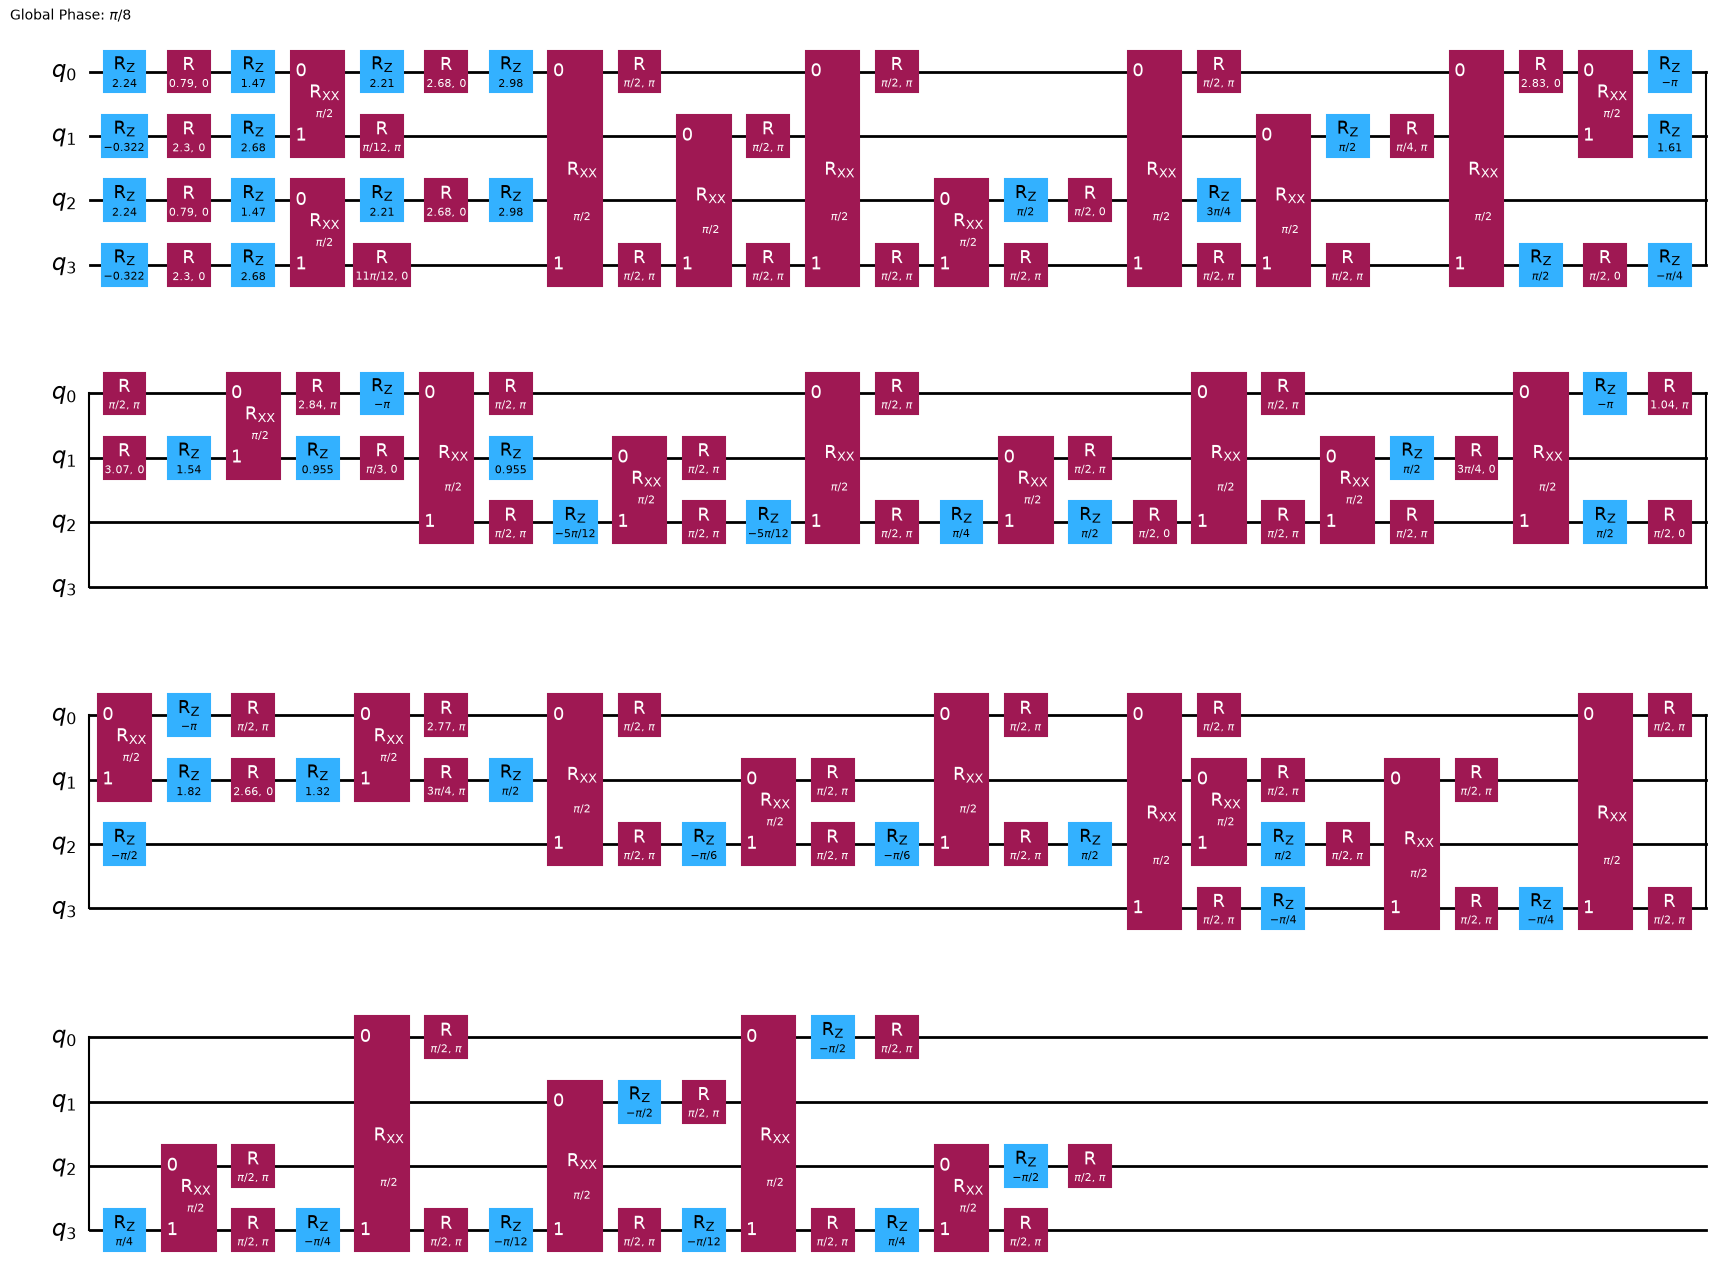

In [4]:
qcsuptrans.draw("mpl")

measurement settings: 9
qutrit_qubits: ((0, 1), (2, 3))
first setting: ('A0', 'B0')


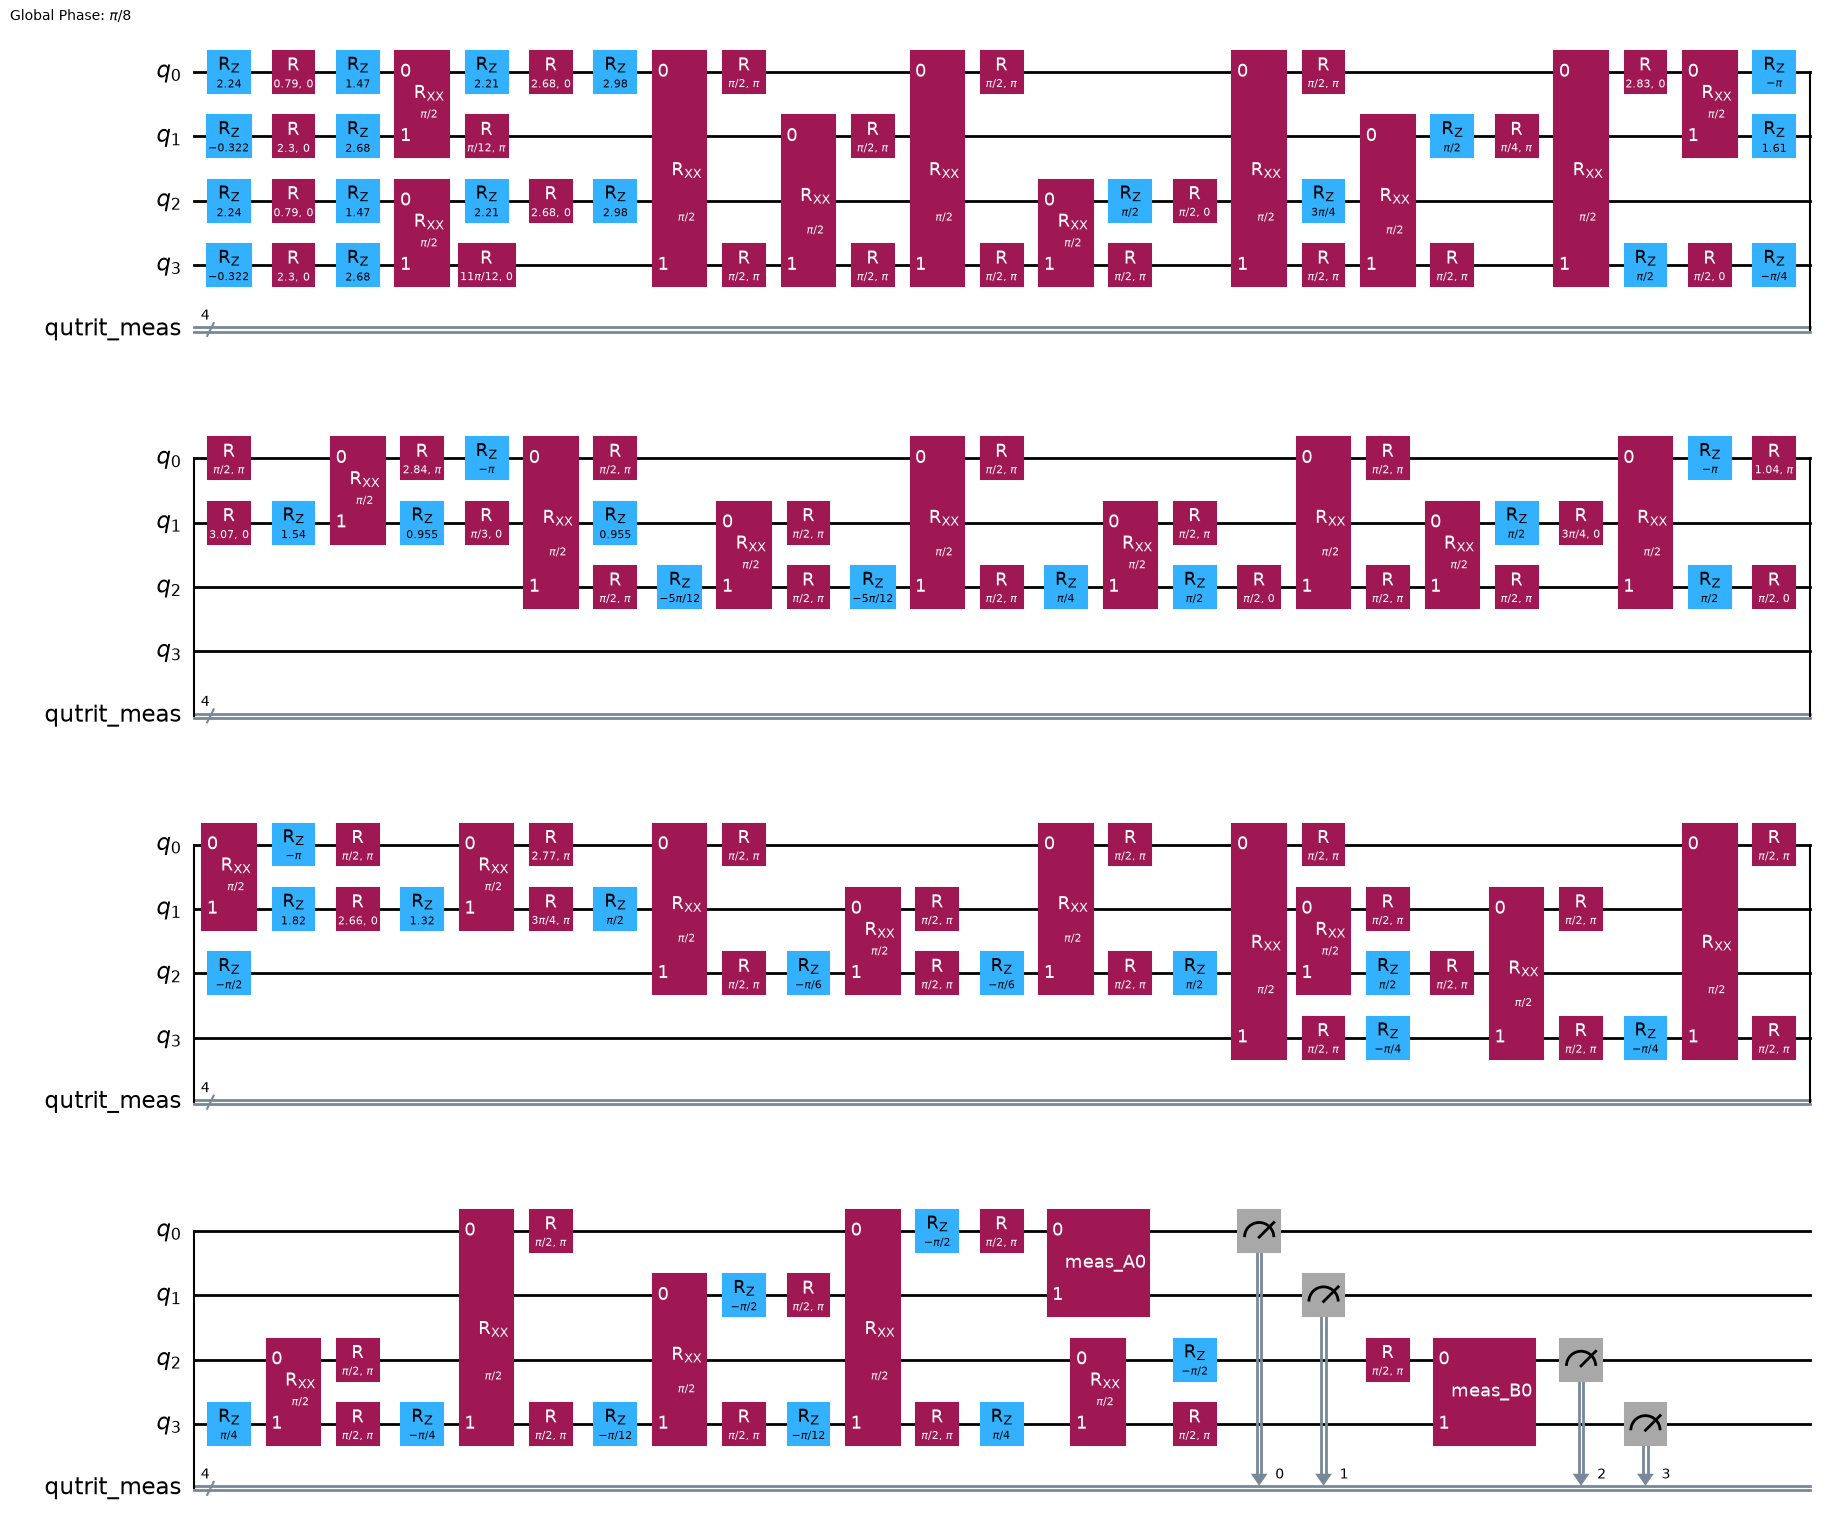

In [5]:
qutrit_qubits = ((0, 1), (2, 3))

sampler_circuits, metadata = build_sampler_circuits_for_candidate(
    candidate="two_qutrit",
    state_circuit=qcsuptrans,
    E=Esup,
    qutrit_qubits=qutrit_qubits,
)

print("measurement settings:", len(sampler_circuits))
print("qutrit_qubits:", metadata["qutrit_qubits"])
print("first setting:", metadata["setting_by_circuit_index"][0])
sampler_circuits[0].draw("mpl")

In [6]:
shots = 1024 * 20

counts_by_setting_aer, run_info_aer = run_sampler_circuits_to_counts_by_setting(
    sampler_circuits,
    metadata,
    shots=shots,
    transpile_circuits=False,
    backend=AerSampler(),
)

bell_value_aer = compute_bell_value_from_counts(
    counts_by_setting_aer,
    metadata["terms"],
    metadata["qutrit_bit_indices_by_setting"],
    **decoding_kwargs_from_metadata(metadata),
)
bell_value_aer

(5.996684736492783-7.438494264988549e-15j)

In [7]:
backend_aqt = load_piast_backend()

aqt_transpile_kwargs = dict(
    backend=backend_aqt,
    optimization_level=3,
    seed_transpiler=9,
    translation_method=AQT_TRANSLATION_METHOD,  # "aqt"
    scheduling_method=AQT_SCHEDULING_METHOD,    # "aqt"
)

aqt_transpile_kwargs

ℹ️ Using cached tokens. If you want to change the account use AuthorizationService.logout() first.


{'backend': <pcss_qapi.aqt.aqt_resource.PCSS_AQTDirectAccessResource at 0x1dbf0ac6310>,
 'optimization_level': 3,
 'seed_transpiler': 9,
 'translation_method': 'aqt',
 'scheduling_method': 'aqt'}

In [8]:
isa_sampler_qc = [transpile(qc, **aqt_transpile_kwargs) for qc in sampler_circuits]

print("first AQT sampler depth:", isa_sampler_qc[0].depth())
print("first AQT sampler ops:", dict(isa_sampler_qc[0].count_ops()))
#isa_sampler_qc[0].draw("mpl")

first AQT sampler depth: 96
first AQT sampler ops: {'r': 78, 'rz': 72, 'rxx': 37, 'measure': 4}


In [9]:
from qiskit_aqt_provider.aqt_resource import OfflineSimulatorResource

In [10]:
from cft_piastq import PiastQClient
from qudits_on_qubits.bell_measurements import (
    build_sampler_circuits_for_candidate,
    canonical_Ez,
    compute_bell_value_from_counts_aqt,
)
import os

In [11]:
client = PiastQClient(
    mode="managed",
    owner="szymon",
    token=os.environ.get("PCSS_QAPI_TOKEN"),
    dashboard_api_url=os.environ.get("CFT_PIASTQ_DASHBOARD_API_URL"),
    dashboard_api_key=os.environ.get("CFT_PIASTQ_DASHBOARD_API_KEY"),
)

cft-piastq: Using managed execution mode.


In [14]:
bell_value, execution = compute_bell_value_from_counts_aqt(
    isa_sampler_qc,
    metadata,
    backend=client.backend,
    shots=200,
    sampler_options={"cft_job_name": "two-qutrit-bell-smoke"}
)

KeyboardInterrupt: 

In [12]:
# counts_by_setting_aqt, run_info_aqt = run_sampler_circuits_to_counts_by_setting(
#     isa_sampler_qc,
#     metadata,
#     shots=2000,
#     transpile_circuits=False,
#     backend=backend_aqt_noise,
# )

# bell_value_aqt = compute_bell_value_from_counts(
#     counts_by_setting_aqt,
#     metadata["terms"],
#     metadata["qutrit_bit_indices_by_setting"],
#     **decoding_kwargs_from_metadata(metadata),
# )
# bell_value_aqt

In [13]:
# metadata["terms"]